In [10]:
from pathlib import Path

import confnotebook


In [11]:
source = Path("../examples/test/full")

files = sorted(source.glob("*.pdf"))

for i, file in enumerate(files):
    print(f"[{i}] {file.stem}")

[0] 10
[1] 126164
[2] 14964427_Енисейская ТГК-13-БРАЗ
[3] 14976087_АвеларСолар Тех-БРАЗ-1
[4] 15120979_Форвард Энерго-БРАЗ-1
[5] 15235008_ОГК-2-БРАЗ-1
[6] 25
[7] 33
[8] 4
[9] 44
[10] 7-1
[11] АС ВНИИМ Менделеева Д.И. - БРАЗ на 31.12.24
[12] АС ВНИИМ Менделеева Д.И. - РУ на 31.12.24
[13] АС КРЕЗОЛ-САЗ на 31.08.25
[14] АС Охрана Металлург-САЗ на 31.12.25
[15] АС РУ- ВОСЬМОЙ ВЕТРОПАРК
[16] АС Фрейт Линк-БРАЗ на 30.09.25
[17] АСР СДД 2 кв.2024 (подп. к-а)
[18] Акт сверки взаимных расчетов №00000379931 от 30.04.2024
[19] Акт сверки №0000
[20] Акт сверки №MOW00-0087974   от 10.06.2024
[21] Акт сверки №ТРБП-000006 от 10.01.2024
[22] Браз-Юнигрин Пауэр
[23] ЕВР-НКАЗ
[24] Неформализованный_первичный_документ_23_ИИА_03_00342_от_31_03
[25] Неформализованный_первичный_документ_23_ИИА_03_02596_от_31_03
[26] Неформализованный_первичный_документ_23_ИИА_03_03623_от_31_03
[27] Неформализованный_первичный_документ_23_ИИА_06_01794_от_30_06
[28] ПР_АС КРЕЗОЛ-САЗ на 31.08.25
[29] ПР_АС Фрейт Линк-

In [12]:
IDX_FILE = 2

In [13]:
from os import mkdir

file = files[IDX_FILE]
output_dir = f"../examples/output/{file.stem}"

if not Path(output_dir).exists():
    mkdir(output_dir)

In [14]:
import numpy as np
from PIL import Image


def save_image(path: str, image: np.ndarray) -> np.ndarray:
    if image.dtype == np.uint8:
        image_u8 = image
    else:
        if float(image.max()) <= 1.0:
            image_u8 = np.clip(image * 255.0, 0, 255).astype(np.uint8)
        else:
            image_u8 = np.clip(image, 0, 255).astype(np.uint8)
    Image.fromarray(image_u8).save(path)

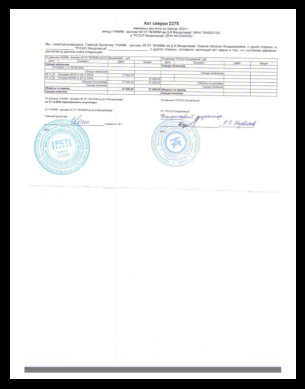

In [15]:
import matplotlib.pyplot as plt

from vision_core.loader.pdf_loader import PDFLoader

img = PDFLoader(pdf_bytes=file.read_bytes()).get_page_image(page_num=0, dpi=200)

plt.imshow(img)
plt.axis("off")
plt.show()

## Deskew из `image_orientation.py` с поэтапной визуализацией

Ниже переносим только deskew-часть алгоритма:
- `_detect_rotation`
- `_detect_edge_rotation`
- `_detect_edge_rotation_peak`

И добавляем диагностические графики, чтобы увидеть, как выбирается угол на реальном изображении.

In [16]:
import math
from dataclasses import dataclass

import cv2
import matplotlib.pyplot as plt
import numpy as np

from vision_core.utils.image_processing import rotate_image


@dataclass
class DeskewDebugConfig:
    edge_scan_range_deg: float = 15.0 # максимальный угол для сканирования краев
    edge_scan_step_deg: float = 0.05 # шаг между углами для сканирования краев
    edge_scan_deviation_deg: float = 1.0 # максимальное отклонение между углами с разных краев
    edge_scan_size: int = -1 # -1 = весь край
    edge_scan_depth: float = 0.5 # доля ширины/высоты для сканирования краев

In [17]:
def _detect_edge_rotation_peak(gray: np.ndarray, cfg: DeskewDebugConfig, shift: tuple[int, int], m: float) -> int:
    h, w = gray.shape
    dx, dy = shift

    if dy == 0:
        scan_size = min(cfg.edge_scan_size if cfg.edge_scan_size != -1 else h, 10000, h)
        max_depth = w // 2
        half = scan_size // 2
        outer_offset = int(abs(m) * half)
        mid = h // 2
        side_x = -outer_offset if dx > 0 else w + outer_offset
        x0 = side_x + half * m
        y0 = mid - half
        step_x, step_y = -m, 1.0
    else:
        scan_size = min(cfg.edge_scan_size if cfg.edge_scan_size != -1 else w, 10000, w)
        max_depth = h // 2
        half = scan_size // 2
        outer_offset = int(abs(m) * half)
        mid = w // 2
        side_y = -outer_offset if dy > 0 else h + outer_offset
        x0 = mid - half
        y0 = side_y - half * m
        step_x, step_y = 1.0, -m

    steps = np.arange(scan_size)
    px = np.round(x0 + steps * step_x).astype(np.int32)
    py = np.round(y0 + steps * step_y).astype(np.int32)

    max_blackness_abs = 255 * scan_size * cfg.edge_scan_depth
    last_blackness = 0
    max_diff = 0
    accumulated = 0

    for dep in range(int(max_depth)):
        cur_px = px + dx * dep
        cur_py = py + dy * dep

        valid = (cur_px >= 0) & (cur_px < w) & (cur_py >= 0) & (cur_py < h)
        blackness = int((255 - gray[cur_py[valid], cur_px[valid]]).sum()) if valid.any() else 0

        diff = blackness - last_blackness
        last_blackness = blackness
        if diff > max_diff:
            max_diff = diff

        accumulated += blackness
        if accumulated >= max_blackness_abs:
            break
    else:
        return 0

    return max_diff


def _detect_edge_rotation(gray: np.ndarray, cfg: DeskewDebugConfig, shift: tuple[int, int]) -> float:
    scan_range_rad = math.radians(cfg.edge_scan_range_deg)
    scan_step_rad = math.radians(cfg.edge_scan_step_deg)

    max_peak = 0
    best_rotation = 0.0
    rotation = 0.0

    while rotation <= scan_range_rad:
        for r in [rotation] if rotation == 0.0 else [rotation, -rotation]:
            peak = _detect_edge_rotation_peak(gray, cfg, shift, math.tan(r))
            if peak > max_peak:
                max_peak = peak
                best_rotation = r
        rotation += scan_step_rad

    return best_rotation


def _detect_rotation(gray: np.ndarray, cfg: DeskewDebugConfig, edges: tuple[bool, bool, bool, bool] = (True, True, True, True)) -> tuple[float, dict]:
    left, top, right, bottom = edges
    edge_values: list[float] = []
    edge_names: list[str] = []

    if left:
        edge_values.append(_detect_edge_rotation(gray, cfg, (1, 0)))
        edge_names.append("left")
    if top:
        edge_values.append(-_detect_edge_rotation(gray, cfg, (0, 1)))
        edge_names.append("top")
    if right:
        edge_values.append(_detect_edge_rotation(gray, cfg, (-1, 0)))
        edge_names.append("right")
    if bottom:
        edge_values.append(-_detect_edge_rotation(gray, cfg, (0, -1)))
        edge_names.append("bottom")

    rotations = np.array(edge_values, dtype=np.float64)
    if rotations.size == 0:
        return 0.0, {"edge_names": [], "rotations": np.array([]), "filtered": np.array([]), "mask": np.array([])}

    median = np.median(rotations)
    mad = np.median(np.abs(rotations - median))
    scan_step_rad = math.radians(cfg.edge_scan_step_deg)
    mask = np.abs(rotations - median) <= max(2 * mad, scan_step_rad)
    filtered = rotations[mask] if mask.any() else rotations

    average = float(np.mean(filtered))
    deviation = float(np.sqrt(np.sum((filtered - average) ** 2)))
    scan_deviation_rad = math.radians(cfg.edge_scan_deviation_deg)
    angle = average if deviation <= scan_deviation_rad else 0.0

    debug = {
        "edge_names": edge_names,
        "rotations": rotations,
        "filtered": filtered,
        "mask": mask,
        "average": average,
        "deviation": deviation,
        "scan_deviation_rad": scan_deviation_rad,
    }
    return angle, debug


def _edge_rotation_profile(gray: np.ndarray, cfg: DeskewDebugConfig, shift: tuple[int, int]) -> tuple[np.ndarray, np.ndarray]:
    scan_range_rad = math.radians(cfg.edge_scan_range_deg)
    scan_step_rad = math.radians(cfg.edge_scan_step_deg)

    angles = []
    peaks = []

    rotation = 0.0
    while rotation <= scan_range_rad:
        for r in [rotation] if rotation == 0.0 else [rotation, -rotation]:
            angles.append(r)
            peaks.append(_detect_edge_rotation_peak(gray, cfg, shift, math.tan(r)))
        rotation += scan_step_rad

    angles = np.array(angles)
    peaks = np.array(peaks)
    order = np.argsort(angles)
    return angles[order], peaks[order]

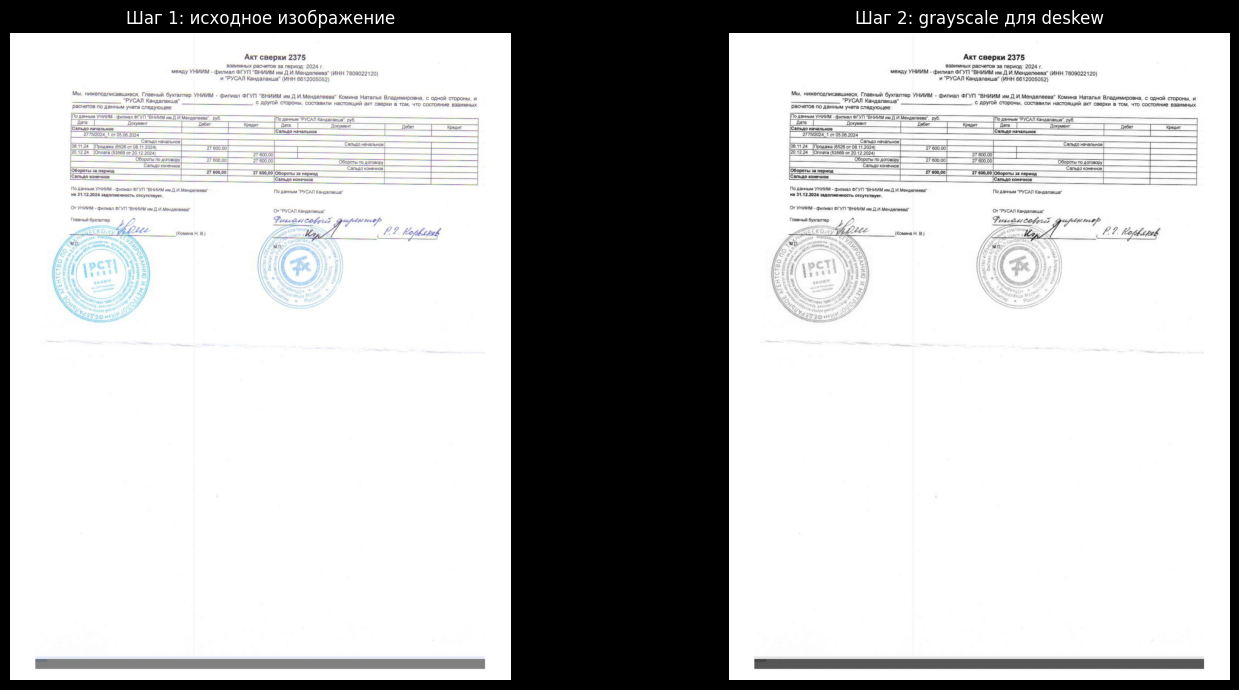

In [18]:
cfg = DeskewDebugConfig()

# Шаг 1. Исходное изображение и оттенки серого
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

fig, ax = plt.subplots(1, 2, figsize=(16, 7))
ax[0].imshow(img)
ax[0].set_title("Шаг 1: исходное изображение")
ax[0].axis("off")

ax[1].imshow(gray, cmap="gray")
ax[1].set_title("Шаг 2: grayscale для deskew")
ax[1].axis("off")

plt.tight_layout()
plt.show()

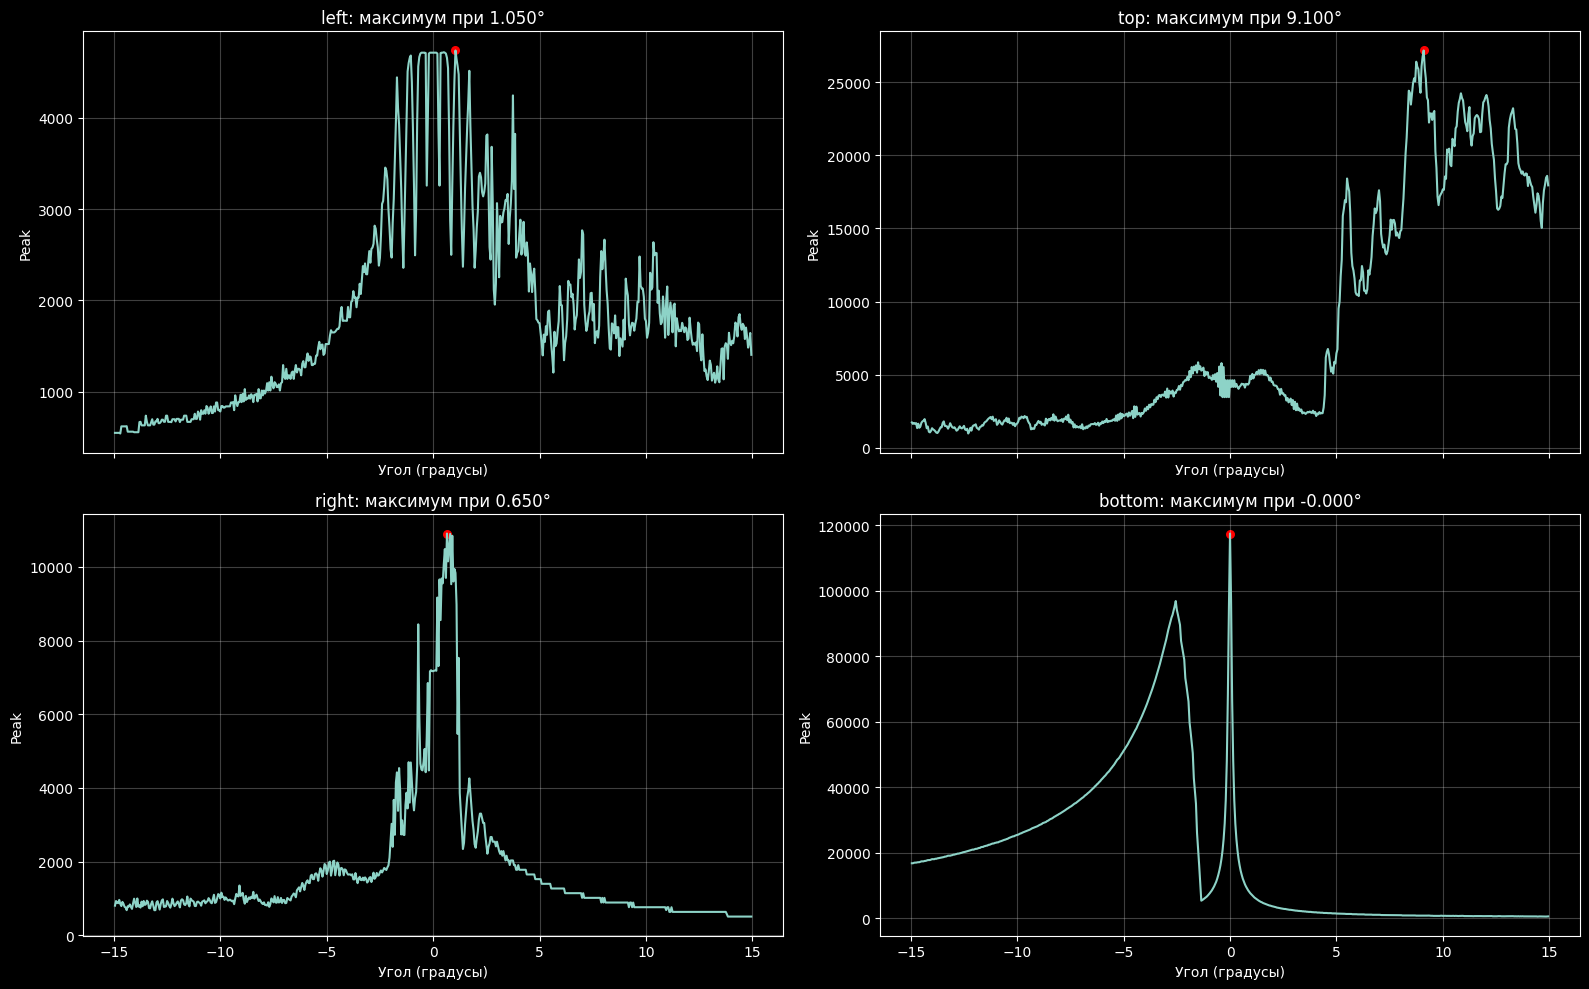

In [19]:
# Шаг 3. Профиль отклика для каждого края: peak(angle)
edge_map = {
    "left": (1, 0),
    "top": (0, 1),
    "right": (-1, 0),
    "bottom": (0, -1),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes = axes.ravel()

for idx, (name, shift) in enumerate(edge_map.items()):
    angles, peaks = _edge_rotation_profile(gray, cfg, shift)

    draw_angles = np.degrees(angles)
    if name in ("top", "bottom"):
        draw_angles = -draw_angles

    ax = axes[idx]
    ax.plot(draw_angles, peaks, linewidth=1.5)
    best_i = int(np.argmax(peaks))
    ax.scatter([draw_angles[best_i]], [peaks[best_i]], color="red", s=30)
    ax.set_title(f"{name}: максимум при {draw_angles[best_i]:.3f}°")
    ax.set_xlabel("Угол (градусы)")
    ax.set_ylabel("Peak")
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

Углы по краям (до фильтрации):
    left:   1.0500°
     top:   9.1000°
   right:   0.6500°
  bottom:  -0.0000°

Углы после MAD-фильтрации: [1.05, 0.65, -0.0]
average: 0.5667°
deviation: 0.7494° (лимит 1.0000°)
Финальный deskew угол: 0.5667°


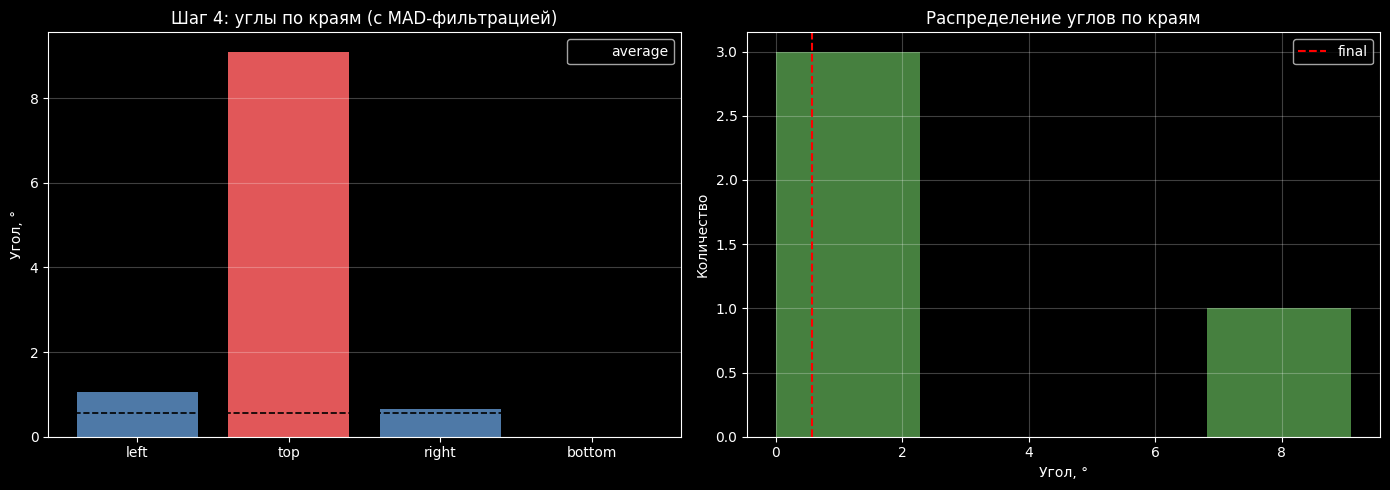

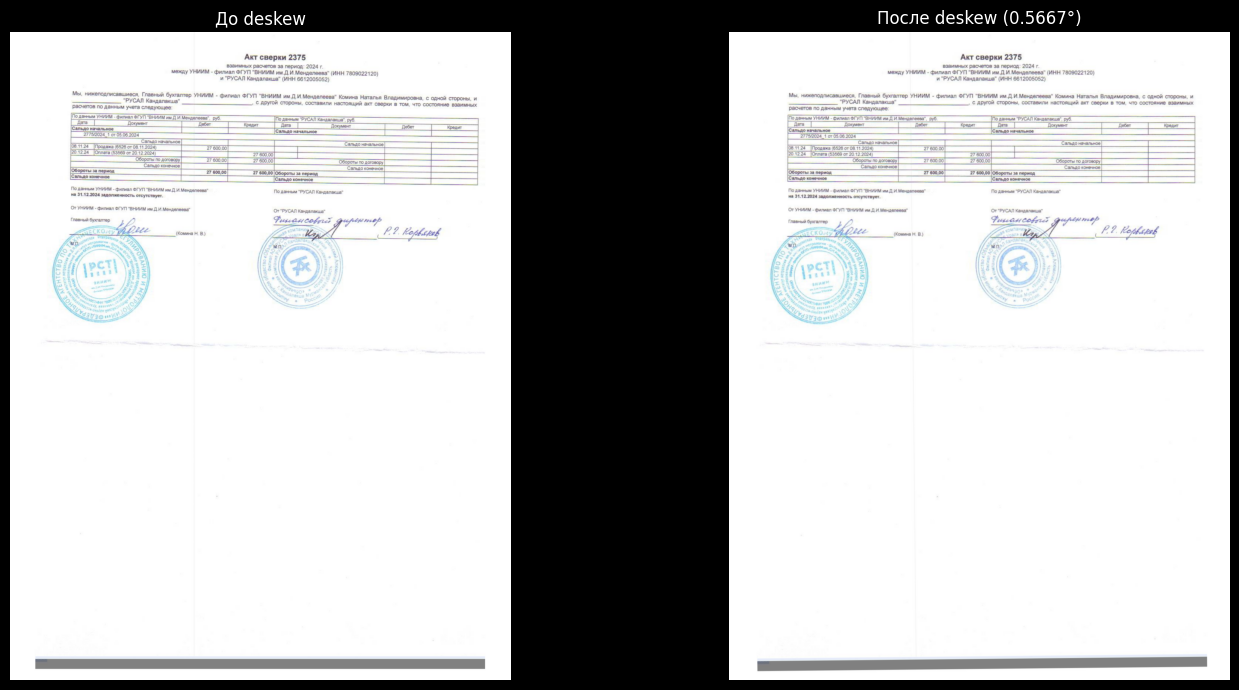

Сохранено: ../examples/output/14964427_Енисейская ТГК-13-БРАЗ/deskew_result.png


In [20]:
# Шаг 4. Итоговые углы по краям + MAD-фильтрация + финальный угол
angle_rad, dbg = _detect_rotation(gray, cfg)

rot_deg = np.degrees(dbg["rotations"])
filtered_deg = np.degrees(dbg["filtered"])
final_deg = np.degrees(angle_rad)
avg_deg = np.degrees(dbg["average"])
dev_deg = np.degrees(dbg["deviation"])
max_dev_deg = np.degrees(dbg["scan_deviation_rad"])

print("Углы по краям (до фильтрации):")
for name, deg in zip(dbg["edge_names"], rot_deg):
    print(f"  {name:>6}: {deg:8.4f}°")

print("\nУглы после MAD-фильтрации:", [round(v, 4) for v in filtered_deg.tolist()])
print(f"average: {avg_deg:.4f}°")
print(f"deviation: {dev_deg:.4f}° (лимит {max_dev_deg:.4f}°)")
print(f"Финальный deskew угол: {final_deg:.4f}°")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(rot_deg))
labels = dbg["edge_names"]
ax[0].bar(x, rot_deg, color=["#4e79a7" if keep else "#e15759" for keep in dbg["mask"]])
ax[0].axhline(avg_deg, color="black", linestyle="--", linewidth=1.2, label="average")
ax[0].set_xticks(x)
ax[0].set_xticklabels(labels)
ax[0].set_ylabel("Угол, °")
ax[0].set_title("Шаг 4: углы по краям (с MAD-фильтрацией)")
ax[0].legend()
ax[0].grid(axis="y", alpha=0.25)

ax[1].hist(rot_deg, bins=min(10, len(rot_deg)), color="#59a14f", alpha=0.8)
ax[1].axvline(final_deg, color="red", linestyle="--", linewidth=1.5, label="final")
ax[1].set_title("Распределение углов по краям")
ax[1].set_xlabel("Угол, °")
ax[1].set_ylabel("Количество")
ax[1].legend()
ax[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Шаг 5. Применяем поворот
rotated = rotate_image(img, final_deg)

fig, ax = plt.subplots(1, 2, figsize=(16, 7))
ax[0].imshow(img)
ax[0].set_title("До deskew")
ax[0].axis("off")

ax[1].imshow(rotated)
ax[1].set_title(f"После deskew ({final_deg:.4f}°)")
ax[1].axis("off")

plt.tight_layout()
plt.show()

save_image(path=f"{output_dir}/deskew_result.png", image=rotated)
print(f"Сохранено: {output_dir}/deskew_result.png")

Альтернативная агрегация:
  filtered (после MAD): [1.05, 0.65, -0.0]
  исключены 0°: [-0.0]
  для усреднения: [1.05, 0.65]
  average_no_zero: 0.8500°
  deviation_no_zero: 0.2828° (лимит 1.0000°)
  финальный угол (без 0°): 0.8500°


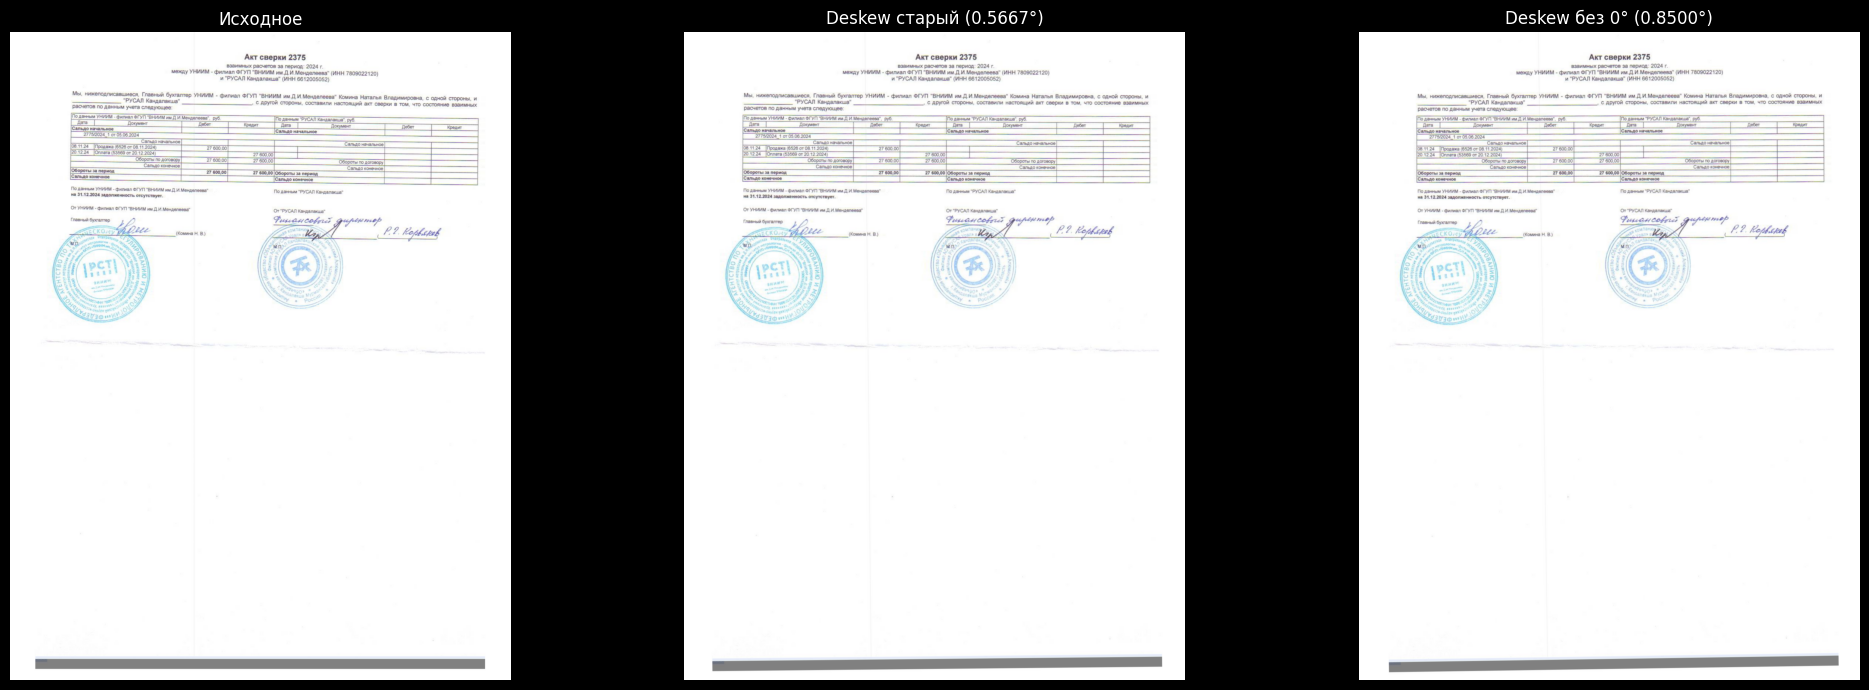

In [21]:
scan_step_rad = math.radians(cfg.edge_scan_step_deg)
filtered_rad = dbg["filtered"]

non_zero_mask = np.abs(filtered_rad) > scan_step_rad
filtered_no_zero = filtered_rad[non_zero_mask] if non_zero_mask.any() else filtered_rad
excluded_zero = filtered_rad[~non_zero_mask] if non_zero_mask.any() else np.array([], dtype=np.float64)

avg_no_zero_rad = float(np.mean(filtered_no_zero))
dev_no_zero_rad = float(np.sqrt(np.sum((filtered_no_zero - avg_no_zero_rad) ** 2)))
limit_rad = dbg["scan_deviation_rad"]
final_no_zero_rad = avg_no_zero_rad if dev_no_zero_rad <= limit_rad else 0.0

print("Альтернативная агрегация:")
print("  filtered (после MAD):", [round(v, 4) for v in np.degrees(filtered_rad).tolist()])
if excluded_zero.size:
    print("  исключены 0°:", [round(v, 4) for v in np.degrees(excluded_zero).tolist()])
print("  для усреднения:", [round(v, 4) for v in np.degrees(filtered_no_zero).tolist()])
print(f"  average_no_zero: {np.degrees(avg_no_zero_rad):.4f}°")
print(f"  deviation_no_zero: {np.degrees(dev_no_zero_rad):.4f}° (лимит {np.degrees(limit_rad):.4f}°)")
print(f"  финальный угол (без 0°): {np.degrees(final_no_zero_rad):.4f}°")

rotated_no_zero = rotate_image(img, np.degrees(final_no_zero_rad))

fig, ax = plt.subplots(1, 3, figsize=(21, 7))
ax[0].imshow(img)
ax[0].set_title("Исходное")
ax[0].axis("off")

ax[1].imshow(rotated)
ax[1].set_title(f"Deskew старый ({final_deg:.4f}°)")
ax[1].axis("off")

ax[2].imshow(rotated_no_zero)
ax[2].set_title(f"Deskew без 0° ({np.degrees(final_no_zero_rad):.4f}°)")
ax[2].axis("off")

plt.tight_layout()
plt.show()

### Шаг 4b: альтернативная агрегация (без 0°)

Если после MAD остаются ненулевые кандидаты, исключаем `0°` из усреднения.
Это убирает смещение итогового угла к нулю при слабом сигнале одного из краёв.

### Шаг 6: как работает виртуальная линия (на одном крае)

В этом шаге:
- выбираем край и угол;
- рисуем положение виртуальной линии при нескольких смещениях `dep`;
- строим графики `blackness(dep)` и `diff(dep) = blackness(dep) - blackness(dep-1)`;
- смотрим, где возникает максимальный скачок (`max diff`).

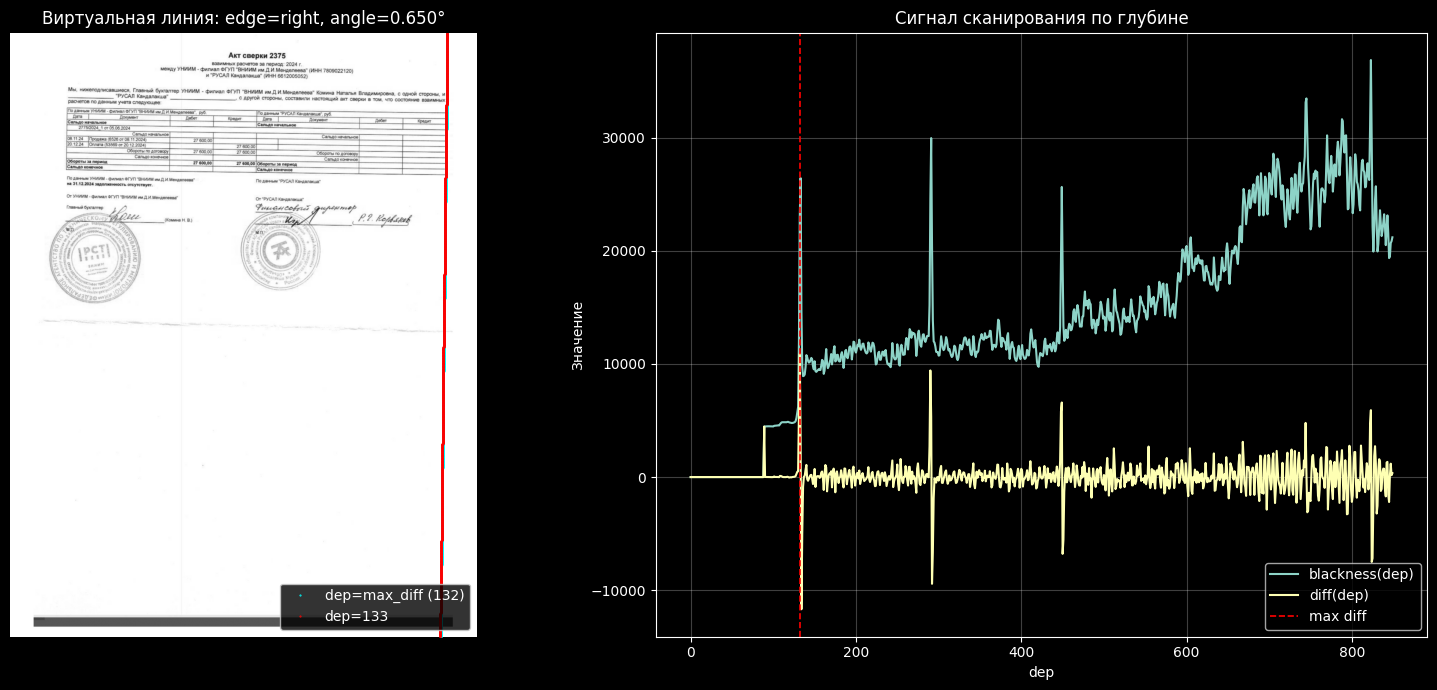

edge=right, angle=0.6500°, max diff at dep=132, max diff=10903


In [22]:
def _edge_scan_trace(gray: np.ndarray, cfg: DeskewDebugConfig, shift: tuple[int, int], angle_deg: float) -> dict:
    h, w = gray.shape
    dx, dy = shift
    m = math.tan(math.radians(angle_deg))

    if dy == 0:
        scan_size = min(cfg.edge_scan_size if cfg.edge_scan_size != -1 else h, 10000, h)
        max_depth = w // 2
        half = scan_size // 2
        outer_offset = int(abs(m) * half)
        mid = h // 2
        side_x = -outer_offset if dx > 0 else w + outer_offset
        x0 = side_x + half * m
        y0 = mid - half
        step_x, step_y = -m, 1.0
    else:
        scan_size = min(cfg.edge_scan_size if cfg.edge_scan_size != -1 else w, 10000, w)
        max_depth = h // 2
        half = scan_size // 2
        outer_offset = int(abs(m) * half)
        mid = w // 2
        side_y = -outer_offset if dy > 0 else h + outer_offset
        x0 = mid - half
        y0 = side_y - half * m
        step_x, step_y = 1.0, -m

    steps = np.arange(scan_size)
    px = np.round(x0 + steps * step_x).astype(np.int32)
    py = np.round(y0 + steps * step_y).astype(np.int32)

    blackness = []
    diffs = []
    last_blackness = 0

    for dep in range(int(max_depth)):
        cur_px = px + dx * dep
        cur_py = py + dy * dep
        valid = (cur_px >= 0) & (cur_px < w) & (cur_py >= 0) & (cur_py < h)

        b = int((255 - gray[cur_py[valid], cur_px[valid]]).sum()) if valid.any() else 0
        d = b - last_blackness
        last_blackness = b

        blackness.append(b)
        diffs.append(d)

    blackness = np.array(blackness, dtype=np.int32)
    diffs = np.array(diffs, dtype=np.int32)
    best_dep = int(np.argmax(diffs)) if diffs.size else 0

    return {
        "px": px,
        "py": py,
        "dx": dx,
        "dy": dy,
        "blackness": blackness,
        "diffs": diffs,
        "best_dep": best_dep,
    }


def _line_coords(trace: dict, dep: int, shape: tuple[int, int]) -> tuple[np.ndarray, np.ndarray]:
    h, w = shape
    cur_px = trace["px"] + trace["dx"] * dep
    cur_py = trace["py"] + trace["dy"] * dep
    valid = (cur_px >= 0) & (cur_px < w) & (cur_py >= 0) & (cur_py < h)
    return cur_px[valid], cur_py[valid]


# Можно менять эти параметры и смотреть, как меняется поведение
inspect_edge = "right"  # left | top | right | bottom
inspect_angle_deg = float(np.degrees(dbg["rotations"][dbg["edge_names"].index(inspect_edge)]))

trace = _edge_scan_trace(gray, cfg, edge_map[inspect_edge], inspect_angle_deg)
best_dep = trace["best_dep"]

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

ax[0].imshow(gray, cmap="gray")
ax[0].set_title(f"Виртуальная линия: edge={inspect_edge}, angle={inspect_angle_deg:.3f}°")
ax[0].axis("off")

colors = ["yellow", "cyan", "red"]
deps = [0, best_dep, min(best_dep + 1, len(trace["diffs"]) - 1)]
labels = ["dep=0", f"dep=max_diff ({best_dep})", f"dep={min(best_dep + 1, len(trace['diffs']) - 1)}"]
for dep, color, label in zip(deps, colors, labels):
    lx, ly = _line_coords(trace, dep, gray.shape)
    if lx.size:
        ax[0].plot(lx, ly, ".", markersize=1.0, color=color, label=label)
ax[0].legend(loc="lower right")

ax[1].plot(trace["blackness"], label="blackness(dep)", linewidth=1.5)
ax[1].plot(trace["diffs"], label="diff(dep)", linewidth=1.5)
ax[1].axvline(best_dep, color="red", linestyle="--", linewidth=1.2, label="max diff")
ax[1].set_title("Сигнал сканирования по глубине")
ax[1].set_xlabel("dep")
ax[1].set_ylabel("Значение")
ax[1].grid(alpha=0.25)
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"edge={inspect_edge}, angle={inspect_angle_deg:.4f}°, max diff at dep={best_dep}, max diff={int(trace['diffs'][best_dep])}")